This step is to build a CNN from scratch first. This becomes the baseline, which we can later compare against transfer-learning models such as ResNet50, EfficientNet, or MobileNet.

#### CNN Baseline

```text

Input: 224 × 224 × 3
          │
          ▼
     Conv2D (32)
          │
      MaxPooling
          │
          ▼
     Conv2D (64)
          │
      MaxPooling
          │
          ▼
     Conv2D (128)
          │
      MaxPooling
          │
          ▼
     Conv2D (256)
          │
      MaxPooling
          │
          ▼
       Flatten
          │
          ▼
     Dense (256)
          │
       Dropout
          │
          ▼
     Dense (4)
          │
          ▼
      Softmax
          │
          ▼
glioma / meningioma / notumor / pituitary

### 1. Import libraries

In [47]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models
from pathlib import Path
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [23]:
#Check TensorFlow
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### 2. Load the processed datasets

In [24]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

In [25]:
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

In [26]:
# Check them
print("Train DataFrame shape:", len(train_df))
print("Validation DataFrame shape:", len(val_df))
print("Test DataFrame shape:", len(test_df))

Train DataFrame shape: 4480
Validation DataFrame shape: 1120
Test DataFrame shape: 1600


### 3. Define classes

In [27]:
CLASSES = [
    'glioma',
    'meningioma',
    'notumor',
    'pituitary'
]

NUM_CLASSES = len(CLASSES)

print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASSES)

Number of classes: 4
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


### 4. Recreate preprocessing

In [28]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [29]:
def preprocess_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize_with_pad(
        image,
        IMG_SIZE,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = image / 255.0

    return image, label

In [30]:
def create_dataset(df, shuffle=False):

    paths = df["filepath"].values
    labels = df["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [31]:
train_dataset = create_dataset(
    train_df,
    shuffle=True
)

validation_dataset = create_dataset(
    val_df,
    shuffle=False
)

test_dataset = create_dataset(
    test_df,
    shuffle=False
)

Verify the data again

In [32]:
images, labels = next(iter(train_dataset))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Pixel min:", tf.reduce_min(images).numpy())
print("Pixel max:", tf.reduce_max(images).numpy())

Image shape: (32, 224, 224, 3)
Label shape: (32,)
Pixel min: 0.0
Pixel max: 1.0


### 5. Build the CNN

In [33]:
model = models.Sequential([
    layers.Input(
        shape = (224, 224, 3)
    ),

    # Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 4
    layers.Conv2D(
        256,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Classification head
    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(
        0.5
    ),

    layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

#### Understand the architecture

The important part is how the image changes.

```text
Initially:
224 × 224 × 3

After first pooling:
112 × 112 × 32

After second:
56 × 56 × 64

After third:
28 × 28 × 128

After fourth:
14 × 14 × 256

Then:
Flatten
    ↓
14 × 14 × 256
    ↓
50,176 values
    ↓
Dense(256)
    ↓
Dense(4)

### 6. Display the model

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,234,756 (50.49 MB)

 Trainable params: 13,234,756 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

### 7. Compile the model

Because we have 4 classes and our labels are integers

```text
0 = glioma
1 = meningioma
2 = notumor
3 = pituitary

we'll use sparse_categorical_crossentropy

In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss = 'sparse_categorical_crossentropy',

    metrics = ['accuracy']
)

In [36]:
print(tf.config.list_physical_devices('GPU'))

[]


#### Why Adam?

Adam automatically adapts the learning rate during training and is a strong starting optimizer for CNNs.

#### Sparse categorical crossentropy?

Our labels are:
```text
0
1
2
3

Therefore: loss="sparse_categorical_crossentropy" is appropriate.

### 8. Train the model

In [37]:
# For the first experiment
EPOCHS = 20

But we should not blindly train for all 20 epochs. We'll use EarlyStopping.

In [38]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [39]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 461ms/step - accuracy: 0.6607 - loss: 0.8247 - val_accuracy: 0.8143 - val_loss: 0.5099
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 65s 456ms/step - accuracy: 0.8158 - loss: 0.4761 - val_accuracy: 0.8687 - val_loss: 0.3445
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 462ms/step - accuracy: 0.8775 - loss: 0.3392 - val_accuracy: 0.8804 - val_loss: 0.3140
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 504ms/step - accuracy: 0.9098 - loss: 0.2485 - val_accuracy: 0.9071 - val_loss: 0.2373
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 104s 724ms/step - accuracy: 0.9415 - loss: 0.1638 - val_accuracy: 0.9045 - val_loss: 0.2495
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 104s 728ms/step - accuracy: 0.9527 - loss: 0.1293 - val_accuracy: 0.9152 - val_loss: 0.2519
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 104s 727ms/step - accuracy: 0.9688 - loss: 0.0897 - val_accuracy: 0.9223 - val_loss: 0.2510
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 77s 534ms/step - accuracy: 0.9681 - loss

In [42]:
MODEL_DIR = PROJECT_ROOT / "models" / "classification"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model.save(
    MODEL_DIR / "cnn_baseline.keras"
)

### 9. Plot training accuracy

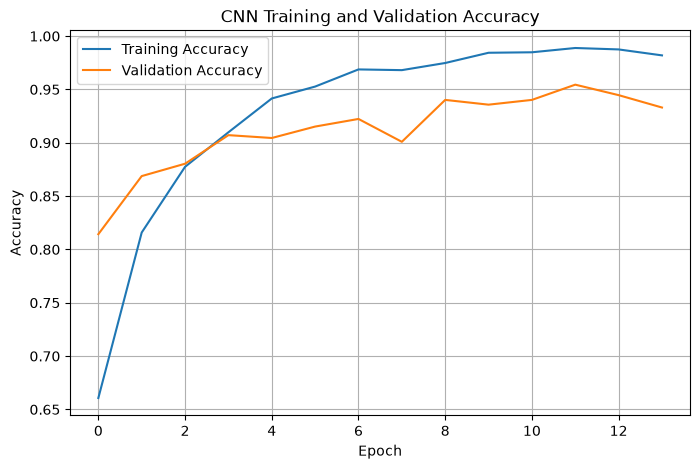

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label = 'Training Accuracy'
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#### 1. Accuracy graph
Your accuracy graph shows:
- Training accuracy steadily increases from ~65% to ~98%.
- Validation accuracy increases from ~81% to a peak of about 94–95%.
- After around Epoch 6–8, training accuracy continues improving while validation accuracy mostly fluctuates around 93–95%.

That means the model has learned useful features, but it is beginning to overfit.In fact, ~94% validation accuracy is a strong baseline.

### 10. Plot loss

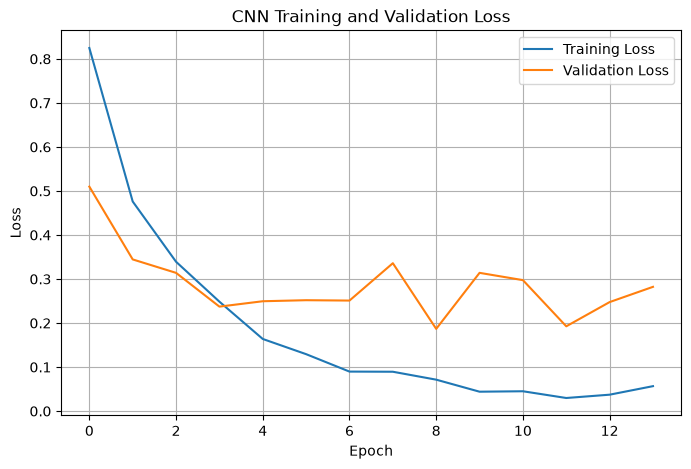

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label = 'Training Loss'
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

The important point is that training loss keeps decreasing while validation loss stops consistently decreasing.
That's a classic sign of overfitting.

#### Is this a problem?

No. This is actually useful information for our project.
We now know:
The CNN can achieve approximately 94% validation accuracy from scratch, but it begins fitting the training data more strongly than the validation data after the middle epochs.

This gives us a meaningful baseline.

In [45]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.8856 - loss: 0.8556
Test Loss: 0.8555786609649658
Test Accuracy: 0.8856250047683716


For final report, 88.56% test accuracy should be the primary baseline result, not 95.45% validation accuracy.

In [46]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [48]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASSES
    )
)

              precision    recall  f1-score   support

      glioma       0.93      0.75      0.83       400
  meningioma       0.82      0.88      0.85       400
     notumor       0.85      1.00      0.92       400
   pituitary       0.97      0.92      0.94       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.88      1600
weighted avg       0.89      0.89      0.88      1600



model has:
```text
Glioma precision = 93%
Glioma recall    = 75%

This means when the model predicts glioma, it is usually correct, but it misses a considerable number of actual glioma images.

#### confusion matrix

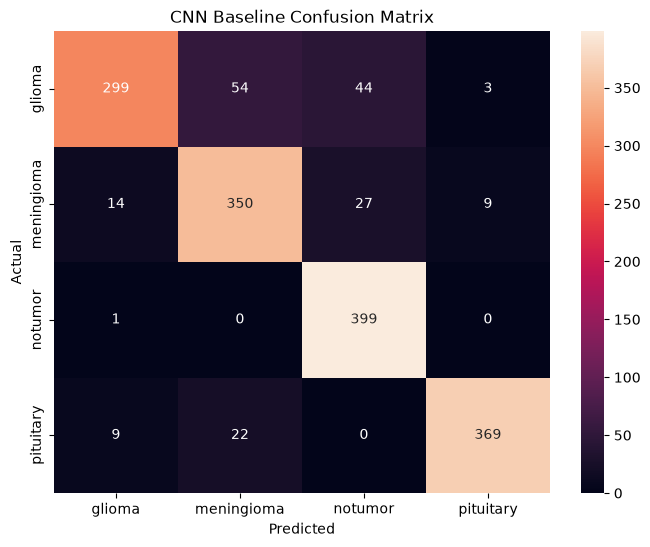

In [49]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Baseline Confusion Matrix")

plt.show()

In here there are out of 400 glioma images

- 299 → correctly identified
- 54  → predicted as meningioma
- 44  → predicted as no tumor
- 3   → predicted as pituitary

So 101/400 glioma images were misclassified.